1. Setup & Imports

In [1]:
!pip install seaborn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

2. Load Dataset

In [3]:
# Upload file in Colab or place in working directory
df = pd.read_csv('/content/seattle-weather.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1461, 6)


,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


3. Data Understanding

In [4]:
print("\nColumns:\n", df.columns)

print("\nUnique Classes:\n", df['weather'].unique())

print("\nClass Distribution:\n", df['weather'].value_counts())


Columns:
 Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather'], dtype='object')

Unique Classes:
 ['drizzle' 'rain' 'sun' 'snow' 'fog']

Class Distribution:
 weather
rain       641
sun        640
fog        101
drizzle     53
snow        26
Name: count, dtype: int64


4. Class Distribution Plot

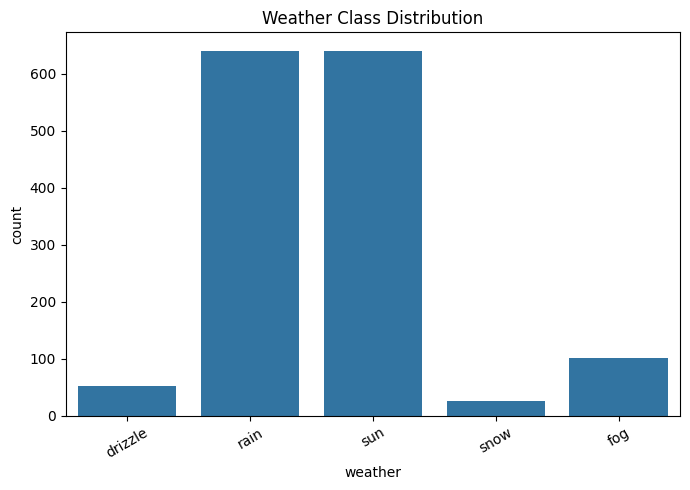

In [5]:
plt.figure(figsize=(7,5))
sns.countplot(x='weather', data=df)

plt.title("Weather Class Distribution")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=300)
plt.show()

5. Preprocessing

In [10]:
from sklearn.preprocessing import LabelEncoder

# Features and target
X = df.drop('weather', axis=1)
y = df['weather']

# Encode target (multi-class)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Class Mapping:", dict(zip(le.classes_, range(len(le.classes_)))))

Class Mapping: {'drizzle': 0, 'fog': 1, 'rain': 2, 'snow': 3, 'sun': 4}


6. Train-Test Split + Scaling

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

7. SVM WITHOUT PCA

In [12]:
svm = SVC(kernel='rbf')

svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)

accuracy_before = accuracy_score(y_test, y_pred)

print("Accuracy BEFORE PCA:", accuracy_before)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy BEFORE PCA: 0.757679180887372

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.00      0.00      0.00        25
           2       0.87      0.82      0.85       120
           3       0.00      0.00      0.00         8
           4       0.69      0.94      0.79       131

    accuracy                           0.76       293
   macro avg       0.31      0.35      0.33       293
weighted avg       0.66      0.76      0.70       293



8. Confusion Matrix (Before PCA + Save)

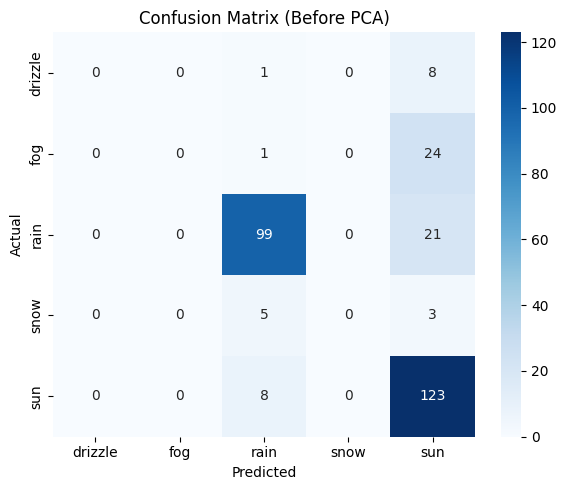

In [13]:
cm_before = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("Confusion Matrix (Before PCA)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrix_before_pca.png", dpi=300)
plt.show()

9. Apply PCA

In [15]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original Features:", X.shape[1])
print("Reduced Features:", X_train_pca.shape[1])

Original Features: 4
Reduced Features: 3


10. PCA Variance Plot

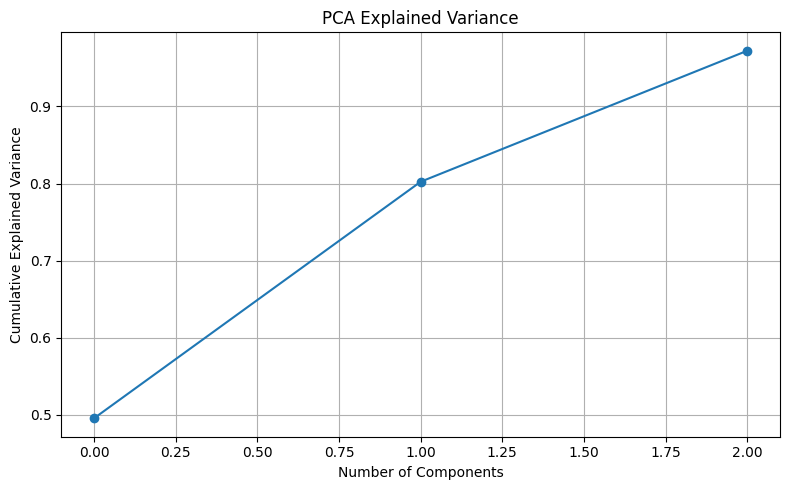

In [16]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid()
plt.tight_layout()
plt.savefig("pca_variance_plot.png", dpi=300)
plt.show()

11. SVM WITH PCA

In [17]:
svm_pca = SVC(kernel='rbf')

svm_pca.fit(X_train_pca, y_train)
y_pred_pca = svm_pca.predict(X_test_pca)

accuracy_after = accuracy_score(y_test, y_pred_pca)

print("Accuracy AFTER PCA:", accuracy_after)
print("\nClassification Report:\n", classification_report(y_test, y_pred_pca))

Accuracy AFTER PCA: 0.7747440273037542

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.00      0.00      0.00        25
           2       0.94      0.81      0.87       120
           3       0.00      0.00      0.00         8
           4       0.68      0.99      0.81       131

    accuracy                           0.77       293
   macro avg       0.33      0.36      0.34       293
weighted avg       0.69      0.77      0.72       293



12. Confusion Matrix (After PCA + Save)

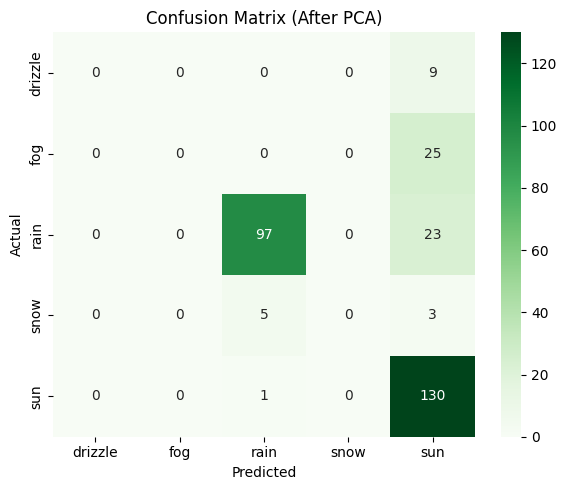

In [18]:
cm_after = confusion_matrix(y_test, y_pred_pca)

plt.figure(figsize=(6,5))
sns.heatmap(cm_after, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("Confusion Matrix (After PCA)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrix_after_pca.png", dpi=300)
plt.show()

13. Accuracy Comparison Graph

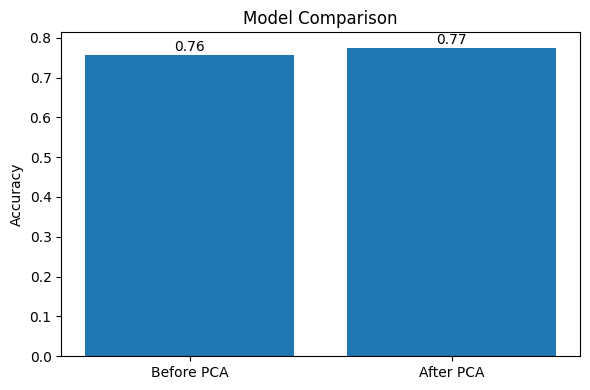

In [19]:
plt.figure(figsize=(6,4))

models = ["Before PCA", "After PCA"]
accuracies = [accuracy_before, accuracy_after]

plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Comparison")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=300)
plt.show()

14. Save CSV Results

In [20]:
comparison = pd.DataFrame({
    "Model": ["SVM Before PCA", "SVM After PCA"],
    "Accuracy": [accuracy_before, accuracy_after]
})

comparison.to_csv("model_comparison.csv", index=False)

# Confusion matrices
pd.DataFrame(cm_before).to_csv("cm_before.csv", index=False)
pd.DataFrame(cm_after).to_csv("cm_after.csv", index=False)

# Reports
pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose().to_csv("report_before.csv")
pd.DataFrame(classification_report(y_test, y_pred_pca, output_dict=True)).transpose().to_csv("report_after.csv")

print("All CSV files saved!")

All CSV files saved!


15. Save Models

In [22]:
import joblib

joblib.dump(svm, "svm_before_pca.pkl")
joblib.dump(svm_pca, "svm_after_pca.pkl")

print("Models saved!")

Models saved!
